Extracting features from training video...
Training features shape: (164, 2)
Training HMM...
Model saved as motion_hmm.pkl

Extracting features from test video...
Test features shape: (164, 2)
Log-likelihood of the test sequence: -36.57


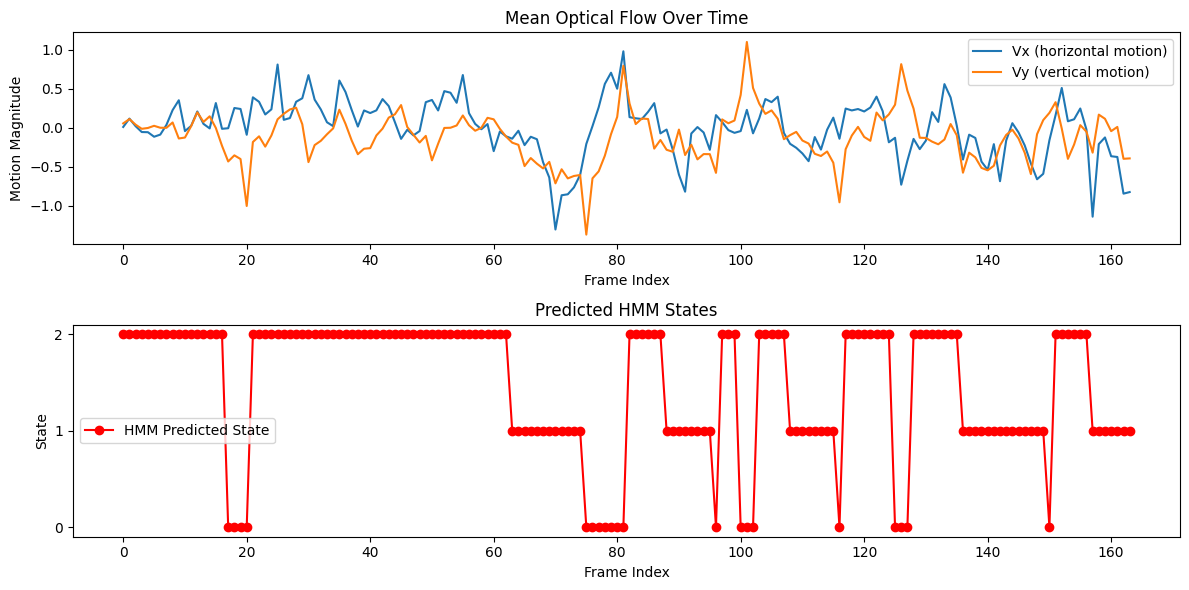

In [5]:
import cv2
import numpy as np
from hmmlearn import hmm
import joblib
import matplotlib.pyplot as plt

def extract_motion_features(video_path):
    cap = cv2.VideoCapture('BABY.avi')
    prev_gray = None
    features = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (320, 240))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_gray is not None:
            flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                                pyr_scale=0.5, levels=3, winsize=15,
                                                iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
            mean_flow = np.mean(flow, axis=(0, 1))  # shape (2,)
            features.append(mean_flow)

        prev_gray = gray

    cap.release()
    features = np.array(features)
    return features

def train_hmm(features, n_components=3):
    model = hmm.GaussianHMM(n_components=n_components, covariance_type='diag', n_iter=100)
    model.fit(features)
    return model

def plot_motion_and_states(features, states):
    timesteps = np.arange(len(features))
    vx = features[:, 0]
    vy = features[:, 1]

    plt.figure(figsize=(12, 6))

    # Motion vectors
    plt.subplot(2, 1, 1)
    plt.plot(timesteps, vx, label="Vx (horizontal motion)")
    plt.plot(timesteps, vy, label="Vy (vertical motion)")
    plt.title("Mean Optical Flow Over Time")
    plt.xlabel("Frame Index")
    plt.ylabel("Motion Magnitude")
    plt.legend()

    # HMM states
    plt.subplot(2, 1, 2)
    plt.plot(timesteps, states, 'ro-', label="HMM Predicted State")
    plt.title("Predicted HMM States")
    plt.xlabel("Frame Index")
    plt.ylabel("State")
    plt.yticks(np.arange(np.max(states) + 1))
    plt.legend()

    plt.tight_layout()
    plt.show()

def main():
    # Paths for training and testing videos
    train_video = "BABY.avi"
    test_video = "BABY.avi"

    print("Extracting features from training video...")
    train_features = extract_motion_features(train_video)
    print(f"Training features shape: {train_features.shape}")

    print("Training HMM...")
    model = train_hmm(train_features)

    # Save the trained model
    joblib.dump(model, "motion_hmm.pkl")
    print("Model saved as motion_hmm.pkl")

    print("\nExtracting features from test video...")
    test_features = extract_motion_features(test_video)
    print(f"Test features shape: {test_features.shape}")

    # Load the model and make predictions
    model = joblib.load("motion_hmm.pkl")
    log_likelihood = model.score(test_features)
    print(f"Log-likelihood of the test sequence: {log_likelihood:.2f}")

    states = model.predict(test_features)
    plot_motion_and_states(test_features, states)

if __name__ == "__main__":
    main()


Extracting features from training video...


Model is not converging.  Current: 733.4712411392137 is not greater than 733.5898853480744. Delta is -0.11864420886070093


Training features shape: (140, 2)
Training HMM...
Model saved as motion_hmm.pkl

Extracting features from test video...
Test features shape: (140, 2)
Log-likelihood of the test sequence: 733.24


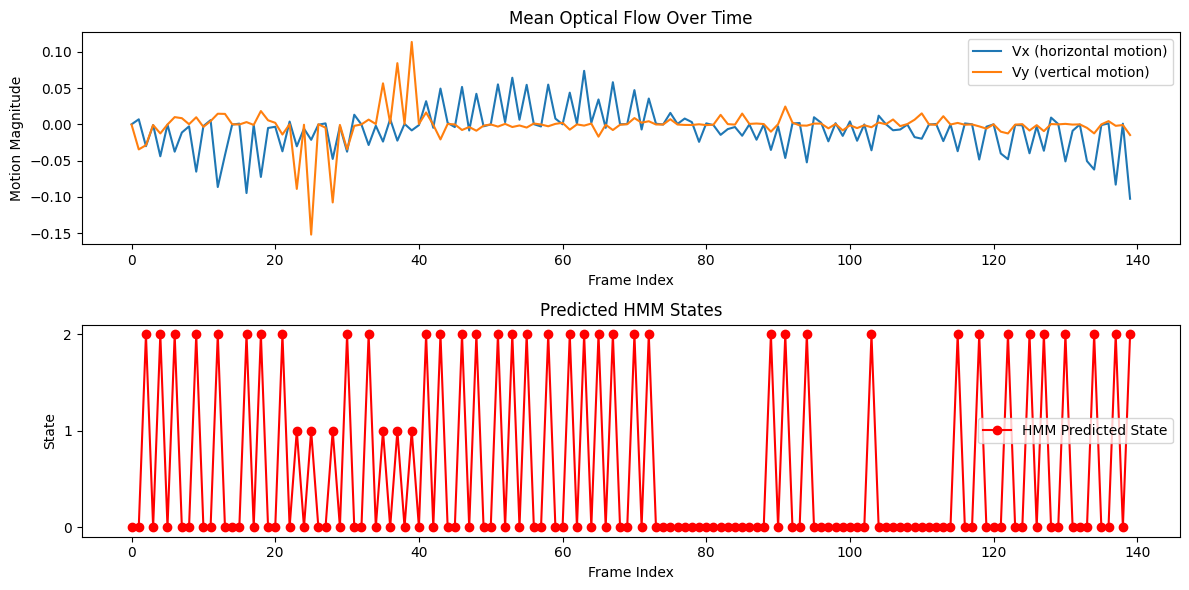

In [6]:
import cv2
import numpy as np
from hmmlearn import hmm
import joblib
import matplotlib.pyplot as plt

def extract_motion_features(video_path):
    cap = cv2.VideoCapture('VIDEO.avi')
    prev_gray = None
    features = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (320, 240))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_gray is not None:
            flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                                pyr_scale=0.5, levels=3, winsize=15,
                                                iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
            mean_flow = np.mean(flow, axis=(0, 1))  # shape (2,)
            features.append(mean_flow)

        prev_gray = gray

    cap.release()
    features = np.array(features)
    return features

def train_hmm(features, n_components=3):
    model = hmm.GaussianHMM(n_components=n_components, covariance_type='diag', n_iter=100)
    model.fit(features)
    return model

def plot_motion_and_states(features, states):
    timesteps = np.arange(len(features))
    vx = features[:, 0]
    vy = features[:, 1]

    plt.figure(figsize=(12, 6))

    # Motion vectors
    plt.subplot(2, 1, 1)
    plt.plot(timesteps, vx, label="Vx (horizontal motion)")
    plt.plot(timesteps, vy, label="Vy (vertical motion)")
    plt.title("Mean Optical Flow Over Time")
    plt.xlabel("Frame Index")
    plt.ylabel("Motion Magnitude")
    plt.legend()

    # HMM states
    plt.subplot(2, 1, 2)
    plt.plot(timesteps, states, 'ro-', label="HMM Predicted State")
    plt.title("Predicted HMM States")
    plt.xlabel("Frame Index")
    plt.ylabel("State")
    plt.yticks(np.arange(np.max(states) + 1))
    plt.legend()

    plt.tight_layout()
    plt.show()

def main():
    # Paths for training and testing videos
    train_video = "'VIDEO.avi'"
    test_video = "'VIDEO.avi'"

    print("Extracting features from training video...")
    train_features = extract_motion_features(train_video)
    print(f"Training features shape: {train_features.shape}")

    print("Training HMM...")
    model = train_hmm(train_features)

    # Save the trained model
    joblib.dump(model, "motion_hmm.pkl")
    print("Model saved as motion_hmm.pkl")

    print("\nExtracting features from test video...")
    test_features = extract_motion_features(test_video)
    print(f"Test features shape: {test_features.shape}")

    # Load the model and make predictions
    model = joblib.load("motion_hmm.pkl")
    log_likelihood = model.score(test_features)
    print(f"Log-likelihood of the test sequence: {log_likelihood:.2f}")

    states = model.predict(test_features)
    plot_motion_and_states(test_features, states)

if __name__ == "__main__":
    main()
